## Preparing the data for YOLO

* YOLO needs one txt file per bounding box. With this format: class_id ,x_center, y_center, width, height
* All the lengths and coordinates need to be normalized

In [ ]:
class_mapping = {
    "RBC": 0,
    "WBC": 1,
    "Platelets": 2
}

In [ ]:
import os
import shutil
import random
import cv2

### Shuffle and split the dataset into training and validation sets and put them in their folders

In [ ]:
source_images_dir = "images"
dataset_root = "dataset"

In [ ]:
all_filenames = [f for f in os.listdir(source_images_dir)]

random.seed(42) # For reproducibility of results
random.shuffle(all_filenames)

split_index = int(len(all_filenames) * 0.8)
train_files = all_filenames[:split_index]
val_files = all_filenames[split_index:]

for filename in train_files:
    src = os.path.join(source_images_dir, filename)
    dst = os.path.join(dataset_root, "train", "images", filename)
    shutil.copy(src, dst)

for filename in val_files:
    src = os.path.join(source_images_dir, filename)
    dst = os.path.join(dataset_root, "val", "images", filename)
    shutil.copy(src, dst)

### Read the bounding box annotations from CSV and convert to YOLO format according to the splits

In [ ]:
class_mapping = {"RBC": 0, "WBC": 1, "Platelets": 2}

with open('data.csv', 'r') as f:
    for line in f:
        (filename, class_name, x1, y1, x2, y2) = line.strip().split(',')

        if filename in train_files:
            split_folder = "train"
        else:
            split_folder = "val"

        class_id = class_mapping[class_name]
        width = int(x2) - int(x1)
        height = int(y2) - int(y1)
        x_center = int(x1) + width / 2
        y_center = int(y1) + height / 2
        img = cv2.imread(f"images/{filename}")
        img_height, img_width = img.shape[:2]
        x_center /= img_width
        y_center /= img_height
        width /= img_width
        height /= img_height
        txt_filename = filename.rsplit('.', 1)[0] + ".txt"
        dst_txt_path = os.path.join(dataset_root, split_folder, "labels", txt_filename)

        with open(dst_txt_path, 'a') as out_f:
            out_f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

In [3]:
!pip install ultralytics -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.1 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
import kagglehub
path = kagglehub.dataset_download("omarelhakim0/blood-object-detection",force_download=True)

100%|██████████| 7.38M/7.38M [00:00<00:00, 107MB/s]

Extracting files...


In [8]:
import os
import yaml
from pathlib import Path

# --- 1. Find the dataset automatically ---
# We look for a folder named "train" that contains an "images" folder
print("Searching for dataset...")
found_root = None

for root, dirs, files in os.walk('/'): # Search from root
    if 'train' in dirs and 'val' in dirs:
        # Check if 'train' has 'images' inside
        if os.path.exists(os.path.join(root, 'train', 'images')):
            found_root = root
            break

if not found_root:
    print("❌ Could not find the dataset! Did you run the download/unzip code?")
else:
    print(f"✅ Found dataset at: {found_root}")

    # --- 2. Create the Dynamic YAML file ---
    # We create a dictionary with the RELATIVE structure you asked for
    config = {
        'path': '.',              # This means "Start looking from this file's folder"
        'train': '/root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/train/images',  # Relative to 'path'
        'val': '/root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/val/images',      # Relative to 'path'
        'nc': 3,
        'names': ['RBC', 'WBC', 'Platelets']
    }

    # --- 3. Save it inside the dataset folder ---
    yaml_path = os.path.join(found_root, 'data.yaml')

    with open(yaml_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)

    print(f"✅ Created config file at: {yaml_path}")
    print("Copy the path below for your training command:")
    print("-" * 30)
    print(f"data='{yaml_path}'")
    print("-" * 30)

Searching for dataset...
✅ Found dataset at: /root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset
✅ Created config file at: /root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/data.yaml
Copy the path below for your training command:
------------------------------
data='/root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/data.yaml'
------------------------------


In [9]:
results = model.train(
    data='/root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/data.yaml',
    epochs=15,
    imgsz=640,
    project='blood_cell_project',
    name='yolov8_run',
    amp=False  # <--- ADD THIS LINE to skip the broken check
)

metrics = model.val()
print(f"mAP50: {metrics.box.map50}")

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_run2, nbs=64, nms=False, opset=None, optimize=False, optimizer


image 1/1 /root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/val/images/BloodImage_00165.jpg: 480x640 19 RBCs, 1 WBC, 108.9ms
Speed: 2.1ms preprocess, 108.9ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)


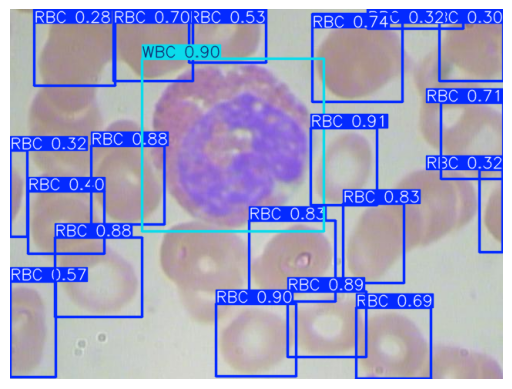

Saved prediction_sample.jpg


In [10]:
import matplotlib.pyplot as plt
import glob
import random
from ultralytics import YOLO

# 1. Load your best trained model
# (Adjust path if needed. It's usually in runs/detect/yolov8_run/weights/best.pt)
model = YOLO('/content/blood_cell_project/yolov8_run/weights/best.pt')

# 2. Pick a random image from your Validation set
val_images = glob.glob('/root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/val/images/*.jpg') # Adjust path to where your val images are
test_img = val_images[random.randint(0, len(val_images))]

# 3. Run Inference
results = model.predict(test_img)

# 4. Show and Save the result
for result in results:
    im_array = result.plot()  # plot() draws the boxes on the image
    plt.imshow(im_array[..., ::-1])  # Convert BGR to RGB for matplotlib
    plt.axis('off')
    plt.show()

    # Save this image to put in your report
    plt.imsave('prediction_sample.jpg', im_array[..., ::-1])
    print("Saved prediction_sample.jpg")

In [ ]:
s

In [ ]:
s

In [13]:
from ultralytics import YOLO
model = YOLO('yolov5n.pt')

PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.



In [14]:
results = model.train(
    data='/root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/data.yaml',
    epochs=15,
    imgsz=640,
    project='blood_cell_project',
    name='yolov5_run',
    amp=False  # <--- ADD THIS LINE to skip the broken check
)

metrics = model.val()
print(f"mAP50: {metrics.box.map50}")

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov5_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=


image 1/1 /root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/val/images/BloodImage_00353.jpg: 480x640 24 RBCs, 1 WBC, 6.4ms
Speed: 1.2ms preprocess, 6.4ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


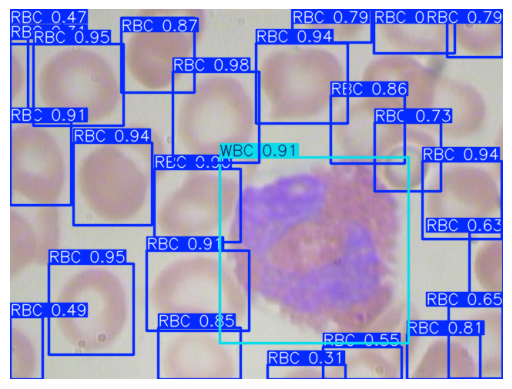

Saved prediction_sample.jpg


In [16]:
import matplotlib.pyplot as plt
import glob
import random
from ultralytics import YOLO

# 1. Load your best trained model
# (Adjust path if needed. It's usually in runs/detect/yolov8_run/weights/best.pt)
model = YOLO('/content/blood_cell_project/yolov8_run/weights/best.pt')

# 2. Pick a random image from your Validation set
val_images = glob.glob('/root/.cache/kagglehub/datasets/omarelhakim0/blood-object-detection/versions/2/dataset/val/images/*.jpg') # Adjust path to where your val images are
test_img = val_images[random.randint(0, len(val_images))]

# 3. Run Inference
results = model.predict(test_img)

# 4. Show and Save the result
for result in results:
    im_array = result.plot()  # plot() draws the boxes on the image
    plt.imshow(im_array[..., ::-1])  # Convert BGR to RGB for matplotlib
    plt.axis('off')
    plt.show()

    # Save this image to put in your report
    plt.imsave('prediction_sample.jpg', im_array[..., ::-1])
    print("Saved prediction_sample.jpg")